In [32]:
import scanpy as sc
import treedata as td
import pycea as py
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import pandas as pd

# Import utility functions made by Katie
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')

from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom

In [33]:
from Moslin.utility import add_gene_expression_to_tree, add_obs_to_tree, add_node_attrs_to_edges, flag_mixed_nodes

In [34]:
import matplotlib.colors as mcolors
palette_template = mcolors.TABLEAU_COLORS

In [5]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/"
output_path_plot = base_path+plot_dir+"/JCF_FHF_SHF_analysis/"
adata_fname = "Processed_data/E7_5.h5td"

In [42]:
adata = td.read_h5td(output_path_data+"Processed_data/E8_0.h5td")
# adata = td.read_h5td(output_path_data+"Processed_data/E8_5.h5td")
adata.X = adata.layers["Raw_count"]

In [43]:
Cardiac_cell_types = {'Juxtacardiac field': 'Juxtacardiac field' , 
                      'First heart field': 'First heart field', 
                      'Second heart field': 'Second heart field',
                        'Anterior mesoderm' : 'anterior SHF' }

In [44]:
adata.obs["Cardiac_cell_types"] = adata.obs['cell_type'].map(Cardiac_cell_types).astype("category")

In [45]:
plot_UMAP_custom(adata=adata,
        umap_coords_obsm="X_umap",
        color_by="Cardiac_cell_types",
        palette = "tab10",
        fig_title="All embryo per time point UMAP",
        output_path_plot=output_path_plot, 
        output_fname="E8_0_embryo_umap_by_Cardiac_Cell_Type.png"
)

In [11]:
adata.uns

{'leiden_0.25': {'params': {'n_iterations': np.int64(2),
   'random_state': np.int64(0),
   'resolution': np.float64(0.25)}},
 'leiden_0.25_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a'],
       dtype=object),
 'leiden_0.5': {'params': {'n_iterations': np.int64(2),
   'random_state': np.int64(0),
   'resolution': np.float64(0.5)}},
 'leiden_0.5_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
        '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#dbdb8d'],
       dtype=object),
 'leiden_1.0': {'params': {'n_iterations': np.int64(2),
   'random_state': np.int64(0),
   'resolution': np.float64(1.0)}},
 'leiden_1.0_colors': array(['#023fa5', '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b',
        '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91', '#d33f6a',
        '

In [47]:
cardiac_cell_type_colors = adata.uns.get("Cardiac_cell_types_colors", None)
if cardiac_cell_type_colors is not None:
    palette = {
        "Juxtacardiac field": cardiac_cell_type_colors[0],
        "First heart field": cardiac_cell_type_colors[1],
        "Second heart field": cardiac_cell_type_colors[2],
        "anterior SHF": cardiac_cell_type_colors[3],
    }
    palette["mixed"] = (0.6, 0.6, 0.6, 1.0)
    palette["nan"] = "gray"
else:
    palette = {
        "Juxtacardiac field": "#1f77b4",
        "First heart field": "#ff7f0e",
        "Second heart field": "#2ca02c",
        "anterior SHF": "#d62728",
        "mixed": (0.6, 0.6, 0.6, 1.0),
        "nan": "gray",
    }

palette


{'Juxtacardiac field': '#1f77b4',
 'First heart field': '#d62728',
 'Second heart field': '#e377c2',
 'anterior SHF': '#17becf',
 'mixed': (0.6, 0.6, 0.6, 1.0),
 'nan': 'gray'}

In [ ]:
def calculate_ancestor_per_cluster(clone_tdata, clone_key, palette, n_cluster=5):

    add_obs_to_tree(clone_tdata, keys=["Cardiac_cell_types", "germ_layer"])
    py.pp.add_depth(clone_tdata)
    py.tl.ancestral_states(clone_tdata, keys="Cardiac_cell_types", tree=clone_key, method="mode")
    # override mixed internal nodes
    flag_mixed_nodes(clone_tdata, clone_key, cell_type_key="Cardiac_cell_types")
    # propagate to edges
    add_node_attrs_to_edges(clone_tdata, keys=["Cardiac_cell_types", "germ_layer"])

    # build palette: take your existing cell type colors and add mixed
    from matplotlib import gridspec

    # Build an LCA distance matrix for the current clone tree
    py.tl.tree_distance(clone_tdata, tree=clone_key, metric="lca", key_added="lca")
    lca_depths = clone_tdata.obsp["lca_distances"]
    if hasattr(lca_depths, "toarray"):
        lca_depths = lca_depths.toarray()

    leaf_order = py.get.leaves(clone_tdata, tree=clone_key)
    cell_types = clone_tdata.obs.loc[leaf_order, "Cardiac_cell_types"].astype(str).to_numpy()

    valid_types = [ct for ct in np.unique(cell_types) if ct not in {"nan", "None", "", "<NA>"}]

    points = []
    depth_count = {ct: {} for ct in Cardiac_cell_types.values()}
    for start in range(0, len(leaf_order), n_cluster):
        window_leaves = leaf_order[start:start + n_cluster]
        if len(window_leaves) < 2:
            continue

        middle_pos = start + 2
        if middle_pos >= len(leaf_order):
            middle_pos = len(leaf_order) - 1

        for ct in valid_types:
            ct_leaves = [leaf for leaf in window_leaves if clone_tdata.obs.loc[leaf, "Cardiac_cell_types"] == ct]
            if len(ct_leaves) < 2:
                continue

            ct_idx = [clone_tdata.obs_names.get_loc(leaf) for leaf in ct_leaves]
            sub = lca_depths[np.ix_(ct_idx, ct_idx)]
            tri = np.triu_indices(len(ct_idx), k=1)
            pair_depths = sub[tri]
            ancestor_depth = float(np.min(pair_depths)) if len(pair_depths) > 0 else 0.0

            points.append((ancestor_depth, middle_pos, ct))
            depth_count[ct][ancestor_depth] = depth_count[ct].get(ancestor_depth, 0) + 1

    # Create a tree panel and a right-side point panel
    fig = plt.figure(figsize=(16, 40))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.08)
    ax_tree = fig.add_subplot(gs[0])
    ax_points = fig.add_subplot(gs[1])

    # Keep the same right-side plotting region as before
    pos = ax_points.get_position()
    new_bottom = 0.121
    new_height = 0.748
    ax_points.set_position([pos.x0, new_bottom, pos.width, new_height])

    # Plotting Tree
    py.pl.branches(
        clone_tdata,
        depth_key="depth",
        color="Cardiac_cell_types",
        palette=palette,
        extend_branches=True,
        angled_branches=True,
        tree=clone_key,
        legend=False,
        ax=ax_tree,
    )
    py.pl.nodes(
        clone_tdata,
        color="Cardiac_cell_types",
        palette=palette,
        nodes="leaves",
        size=10,
        legend=False,
        tree=clone_key,
        ax=ax_tree,
    )
    ax_tree.set_title(f"Lineage tree — {clone_key}", fontsize=14)

    # Plotting the depth scatter in the right-side panel
    for ct in valid_types:
        subset = [p for p in points if p[2] == ct]
        if not subset:
            continue
        xs = [p[0] for p in subset]
        ys = [p[1] for p in subset]
        ax_points.scatter(xs, ys, color=palette.get(ct, "black"), s=40, alpha=0.8, label=ct)

    x_max = max([p[0] for p in points], default=1.0)
    ax_points.set_xlim(0, x_max + 1)
    ax_points.set_ylim(0, len(leaf_order) - 1)
    ax_points.set_xlabel("Ancestor depth")
    ax_points.set_ylabel("Leaf order (bottom -> top)")
    ax_points.set_title("Sliding-window ancestor-depth", fontsize=14)
    ax_points.grid(alpha=0.2)
    ax_points.legend(loc="best", frameon=False)

    all_counts = [count for ct in valid_types for count in depth_count[ct].values()]
    max_count = max(all_counts, default=1)

    # Add a secondary y-axis for histogram counts while keeping the same graph space
    ax_hist = ax_points.twinx()
    ax_points.set_position([pos.x0, new_bottom, pos.width, new_height])

    for ct in valid_types:
        if not depth_count.get(ct):
            continue
        depths = list(depth_count[ct].keys())
        counts = list(depth_count[ct].values())
        if len(depths) == 1:
            bins = np.arange(min(depths) - 0.5, max(depths) + 1.5, 1)
        else:
            bins = np.arange(0, max(depths) + 2, 1)
        ax_hist.hist(
            depths,
            bins=bins,
            weights=counts,
            alpha=0.5,
            color=palette.get(ct, "black"),
            edgecolor=palette.get(ct, "black"),
            label=f"{ct} counts",
            stacked = True
        )
    ax_hist.set_ylim(0, max_count * 10)
    ax_hist.set_ylabel("Histogram share (scaled)")
    ax_hist.set_yticks([])

    plt.tight_layout()
    plt.show()


In [54]:
set(adata.obs['tree'])

{'E8.0-R1-C1',
 'E8.0-R1-C2',
 'E8.0-R1-C3',
 'E8.0-R2-C1',
 'E8.0-R2-C2',
 'E8.0-R3-C1',
 'E8.0-R3-C2',
 'E8.0-R3-C3',
 'E8.0-R3-C4',
 'E8.0-R3-C5',
 'E8.0-R3-C6',
 nan}

/scratch/local/jobs/51500317/ipykernel_3262449/1210434689.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


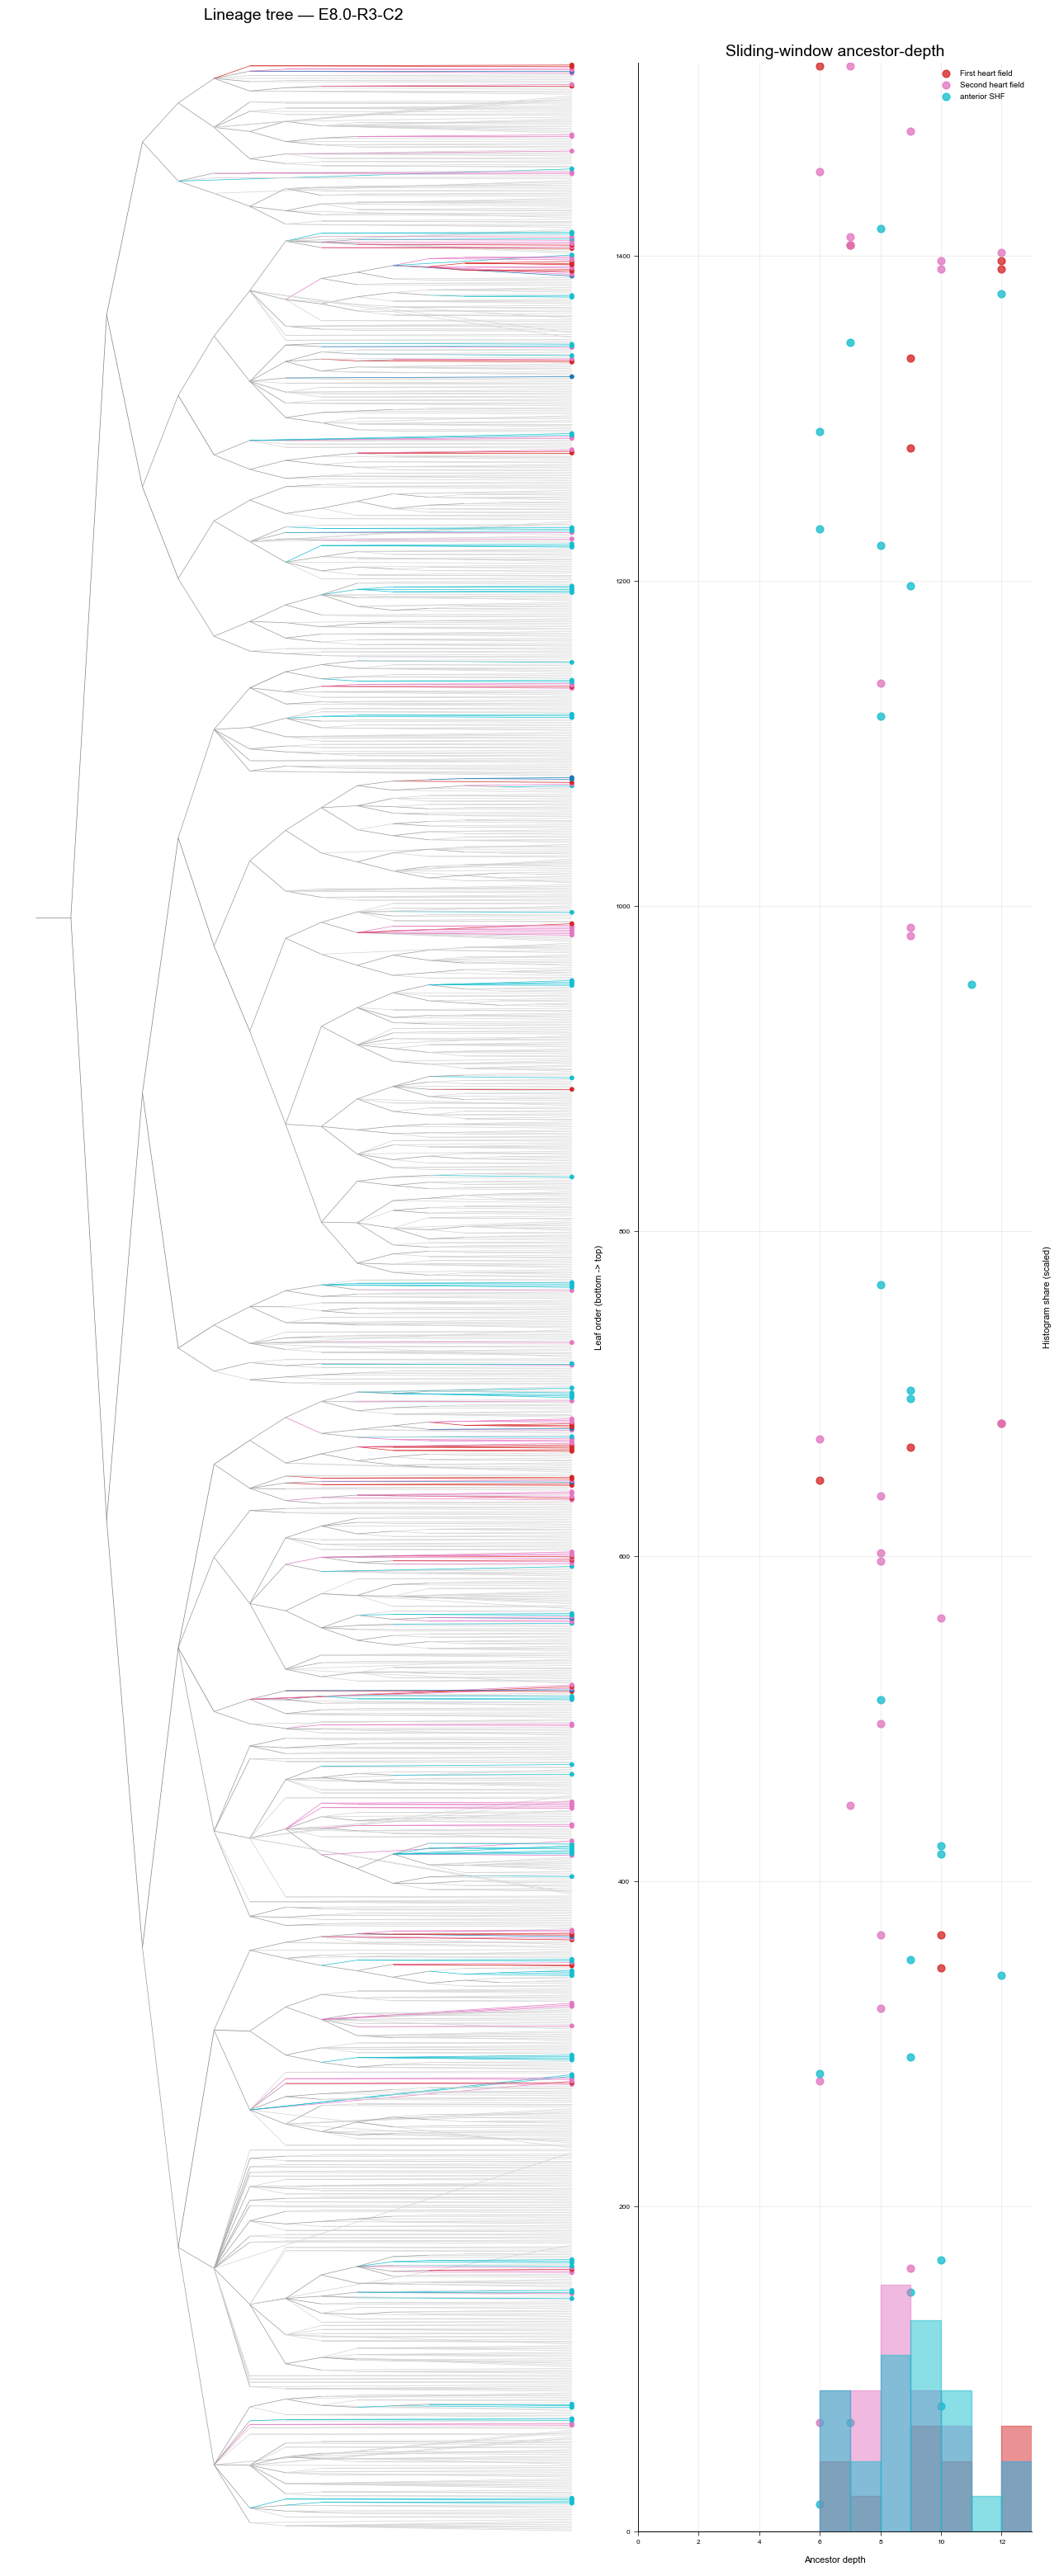

In [98]:
clone_tdata = adata[adata.obs["tree"] == "E8.0-R3-C2"].copy()
calculate_ancestor_per_cluster(clone_tdata, "E8.0-R3-C2", palette=palette)


In [ ]:
for clone_key in set(adata.obs['tree']):
    clone_tdata = adata[adata.obs["tree"] == clone_key].copy()
    calculate_ancestor_per_cluster(clone_tdata, clone_key)

Running E8_0 with 3 replicates
  E8.0-R1: 3 clones


Running E8_0 with 3 replicates
  E8.0-R1: 3 clones


/scratch/local/jobs/51500317/ipykernel_3251975/920736484.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Running E8_0 with 3 replicates
  E8.0-R1: 3 clones


/scratch/local/jobs/51500317/ipykernel_3251975/920736484.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


...

/scratch/local/jobs/51500317/ipykernel_3251975/920736484.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


    E8.0-R1-C2: /project/imoskowitz/yubin/Lineage_Tree_Construction/output_plot/JCF_FHF_SHF_analysis/E8_0_E8_0-R1-C2_tree_with_celltype_points.svg


/scratch/local/jobs/51500317/ipykernel_3251975/920736484.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


    E8.0-R1-C3: /project/imoskowitz/yubin/Lineage_Tree_Construction/output_plot/JCF_FHF_SHF_analysis/E8_0_E8_0-R1-C3_tree_with_celltype_points.svg
  E8.0-R2: 2 clones


KeyboardInterrupt: 

In [7]:
for stage in ["E8_0", "E8_5"]:
    path = f"{output_path_data}Processed_data/{stage}.h5td"
    adata = td.read_h5td(path)
    print(stage, adata.shape)
    print("obs columns:", list(adata.obs.columns))
    for col in ["embryo", "replicate", "sample", "batch", "stage", "tree"]:
        if col in adata.obs.columns:
            print(col, sorted(map(str, adata.obs[col].unique()))[:20])
    print("tree values:", sorted(map(str, adata.obs["tree"].unique()))[:20])
    print()


E8_0 (21942, 78258)
obs columns: ['cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0']
embryo ['E8.0-R1', 'E8.0-R2', 'E8.0-R3']
stage ['E8.0']
tree ['E8.0-R1-C1', 'E8.0-R1-C2', 'E8.0-R1-C3', 'E8.0-R2-C1', 'E8.0-R2-C2', 'E8.0-R3-C1', 'E8.0-R3-C2', 'E8.0-R3-C3', 'E8.0-R3-C4', 'E8.0-R3-C5', 'E8.0-R3-C6', 'nan']
tree values: ['E8.0-R1-C1', 'E8.0-R1-C2', 'E8.0-R1-C3', 'E8.0-R2-C1', 'E8.0-R2-C2', 'E8.0-R3-C1', 'E8.0-R3-C2', 'E8.0-R3-C3', 'E8.0-R3-C4', 'E8.0-R3-C5', 'E8.0-R3-C6', 'nan']

E8_5 (89230, 78258)
obs columns: ['cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0']
embryo ['E8.5-R1', 'E8.5-R2', 'E8.5-R3']
stage ['E8.5']
tree ['